# **Deep Learning-Based Detection of Retinal Diseases from Fundus Images**

**Dataset Link** => https://www.kaggle.com/datasets/chtalhaanwar/riaddisbi21/data

## **Data Downloading**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d chtalhaanwar/riaddisbi21

Dataset URL: https://www.kaggle.com/datasets/chtalhaanwar/riaddisbi21
License(s): unknown
100% 7.43G/7.43G [01:41<00:00, 78.4MB/s]



In [5]:
!unzip -q riaddisbi21.zip

In [6]:
import os
import shutil
import pandas as pd
import numpy as np
import csv
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

%matplotlib inline

## **Preprocessing**

In [7]:
os.makedirs("final_dataset", exist_ok=True)

#### **Training Data**

In [8]:
train_labels_df = pd.read_csv('train_set/RFMiD_Training_Labels.csv')
train_labels_df.head()

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,AION,PT,RT,RS,CRS,EDN,RPEC,MHL,RP,OTHER
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train_labels_df['Disease_Risk'].value_counts()

,count
Disease_Risk,
1,1519
0,401


In [10]:
# Disease Risk = 1 = Abnormal = abnormal_train
# Disease Risk = 0 = Normal = normal_train

abnormal_train=[]
normal_train=[]
with open('train_set/RFMiD_Training_Labels.csv','r') as F:
  reader=csv.reader(F)
  for row in reader:
      if(row[1]=='1'):
        abnormal_train.append(row[0]+'.png')
      if(row[1]=='0'):
        normal_train.append(row[0]+'.png')
F.close()

In [11]:
len(abnormal_train)

1519

In [12]:
parent_dir="final_dataset/Training"
os.makedirs('final_dataset/Training', exist_ok=True)
directory1 = "Abnormal"
directory2 = "Normal"
path1 = os.path.join(parent_dir, directory1)
path2 = os.path.join(parent_dir, directory2)
os.makedirs(path1, exist_ok=True)
os.makedirs(path2, exist_ok=True)

* Copying from `dataset/train_set/Training` => `final_dataset/Training/[Abnormal|Normal]`

In [13]:
save_path = 'final_dataset/Training/Abnormal'
for filename in abnormal_train:
  shutil.copy('train_set/Training/'+filename,save_path)
save_path = 'final_dataset/Training/Normal'
for filename in normal_train:
  shutil.copy('train_set/Training/'+filename,save_path)

#### **Validation Data**

In [14]:
validation_labels_df = pd.read_csv("val_set/RFMiD_Validation_Label.csv")
validation_labels_df.head()

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,AION,PT,RT,RS,CRS,EDN,RPEC,MHL,RP,OTHER
0,1,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
validation_labels_df['Disease_Risk'].value_counts()

,count
Disease_Risk,
1,506
0,134


In [16]:
abnormal_val=[]
normal_val=[]
with open('val_set/RFMiD_Validation_Label.csv','r') as F:
  reader=csv.reader(F)
  for row in reader:
      if(row[1]=='1'):
        abnormal_val.append(row[0]+'.png')
      if(row[1]=='0'):
        normal_val.append(row[0]+'.png')
F.close()

In [17]:
parent_dir="final_dataset/Validation"
os.makedirs(parent_dir, exist_ok=True)
directory1 = "Abnormal"
directory2 = "Normal"
path1 = os.path.join(parent_dir, directory1)
path2 = os.path.join(parent_dir, directory2)
os.makedirs(path1, exist_ok=True)
os.makedirs(path2, exist_ok=True)

In [18]:
save_path = 'final_dataset/Validation/Abnormal'
for filename in abnormal_val:
  shutil.copy('val_set/Validation/'+filename,save_path)
save_path = 'final_dataset/Validation/Normal'
for filename in normal_val:
  shutil.copy('val_set/Validation/'+filename,save_path)

#### **Testing Data**

In [19]:
test_labels_df = pd.read_csv('test_set/RFMiD_Testing_Labels.csv')
test_labels_df.head()

,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,AION,PT,RT,RS,CRS,EDN,RPEC,MHL,RP,OTHER
0,1,1,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [20]:
test_labels_df['Disease_Risk'].value_counts()

,count
Disease_Risk,
1,506
0,134


In [21]:
abnormal_test=[]
normal_test=[]
with open('test_set/RFMiD_Testing_Labels.csv','r') as F:
  reader=csv.reader(F)
  for row in reader:
      if(row[1]=='1'):
        abnormal_test.append(row[0]+'.png')
      if(row[1]=='0'):
        normal_test.append(row[0]+'.png')
F.close()

In [22]:
parent_dir="final_dataset/Testing"
os.makedirs(parent_dir, exist_ok=True)
directory1 = "Abnormal"
directory2 = "Normal"
path1 = os.path.join(parent_dir, directory1)
path2 = os.path.join(parent_dir, directory2)
os.makedirs(path1, exist_ok=True)
os.makedirs(path2, exist_ok=True)

In [23]:
save_path = 'final_dataset/Testing/Abnormal'
for filename in abnormal_test:
  shutil.copy('test_set/Test/'+filename,save_path)
save_path = 'final_dataset/Testing/Normal'
for filename in normal_test:
  shutil.copy('test_set/Test/'+filename,save_path)

#### **Overview of Train, Validation and Test Data**

**Training Data**

In [24]:
train_abnormal_dir = os.path.join('final_dataset/Training/Abnormal')
train_normal_dir = os.path.join('final_dataset/Training/Normal')
train_abnormal_names = os.listdir(train_abnormal_dir)
train_normal_names = os.listdir(train_normal_dir)
print('Total training images with abnormalities:', len(os.listdir(train_abnormal_dir)))
print('Total training images of normal eyes:', len(os.listdir(train_normal_dir)))

Total training images with abnormalities: 1519
Total training images of normal eyes: 401


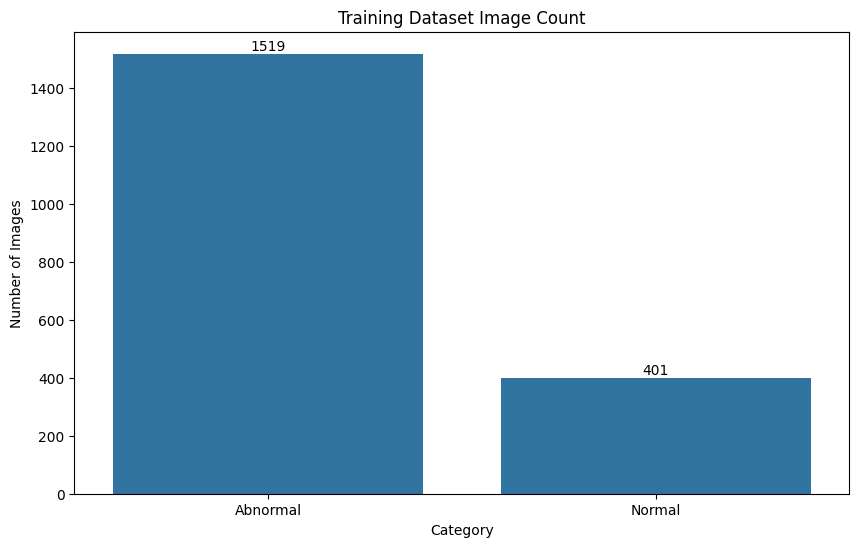

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Get counts
abnormal_count = len(os.listdir(train_abnormal_dir))
normal_count = len(os.listdir(train_normal_dir))

# Create data
labels = ['Abnormal', 'Normal']
counts = [abnormal_count, normal_count]

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(x=labels, y=counts)
ax.bar_label(ax.containers[0], fontsize=10)

plt.title('Training Dataset Image Count')
plt.ylabel('Number of Images')
plt.xlabel('Category')

plt.show()

**Validation Data**

In [26]:
validation_abnormal_dir = os.path.join('final_dataset/Validation/Abnormal')
validation_normal_dir = os.path.join('final_dataset/Validation/Normal')
validation_abnormal_names = os.listdir(validation_abnormal_dir)
validation_normal_names = os.listdir(validation_normal_dir)
print('Total validation images with abnormalities:', len(os.listdir(validation_abnormal_dir)))
print('Total validation images of normal eyes:', len(os.listdir(validation_normal_dir)))

Total validation images with abnormalities: 506
Total validation images of normal eyes: 134


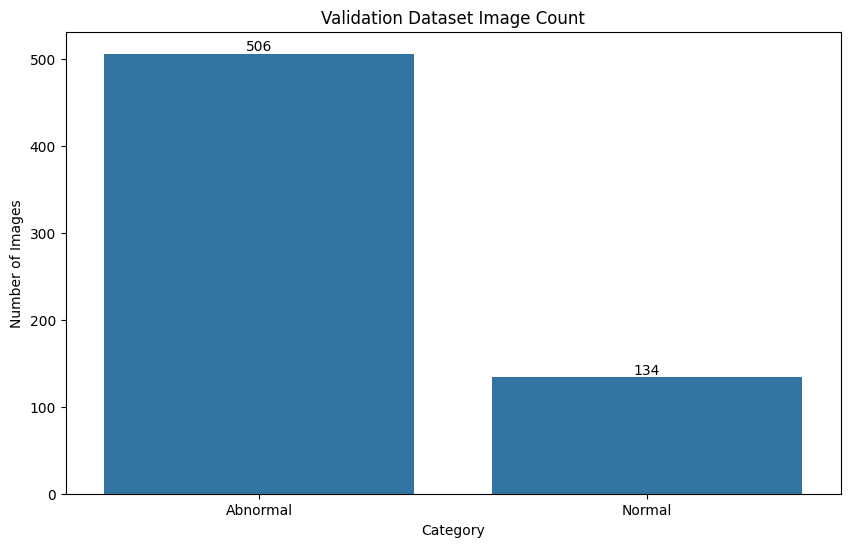

In [27]:
# counts
abnormal_count = len(os.listdir(validation_abnormal_dir))
normal_count = len(os.listdir(validation_normal_dir))

labels = ['Abnormal', 'Normal']
counts = [abnormal_count, normal_count]

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(x=labels, y=counts)
ax.bar_label(ax.containers[0], fontsize=10)

plt.title('Validation Dataset Image Count')
plt.ylabel('Number of Images')
plt.xlabel('Category')

plt.show()

**Test Data**

In [28]:
test_abnormal_dir = os.path.join('final_dataset/Testing/Abnormal')
test_normal_dir = os.path.join('final_dataset/Testing/Normal')
test_abnormal_names = os.listdir(test_abnormal_dir)
test_normal_names = os.listdir(test_normal_dir)
print('Total testing images with abnormalities:', len(os.listdir(test_abnormal_dir)))
print('Total testing images of normal eyes:', len(os.listdir(test_normal_dir)))

Total testing images with abnormalities: 506
Total testing images of normal eyes: 134


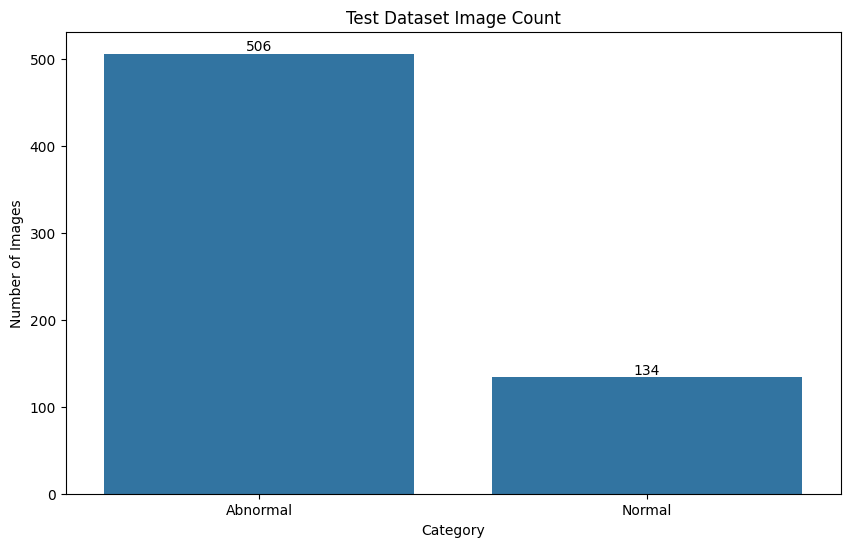

In [29]:
# counts
abnormal_count = len(os.listdir(test_abnormal_dir))
normal_count = len(os.listdir(test_normal_dir))

labels = ['Abnormal', 'Normal']
counts = [abnormal_count, normal_count]

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(x=labels, y=counts)
ax.bar_label(ax.containers[0], fontsize=10)

plt.title('Test Dataset Image Count')
plt.ylabel('Number of Images')
plt.xlabel('Category')

plt.show()

#### **Sample Dataset Images**

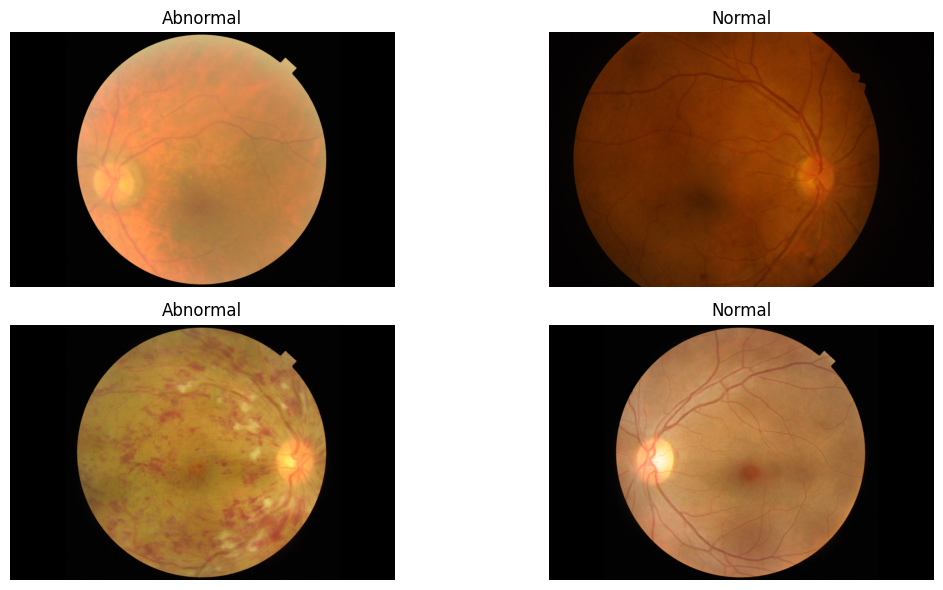

In [30]:
import random
from PIL import Image

# Path to your train folder
train_dir = "final_dataset/Training"

# Get class names (folders inside train_dir)
classes = os.listdir(train_dir)

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Loop through each class and pick 2 random images
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)

    # Pick 2 random images
    sample_imgs = random.sample(images, 2)

    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        # Plot in 2x4 grid
        ax = axes[j, i]
        ax.imshow(img)
        ax.set_title(f"{class_name}", fontsize=12)
        ax.axis("off")

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [58]:
train_dir = "final_dataset/Training"
val_dir = "final_dataset/Validation"
test_dir = "final_dataset/Testing"

In [59]:
img_size=(128, 128)
batch_size = 64

In [60]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1920 images belonging to 2 classes.


In [61]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 640 images belonging to 2 classes.
Found 640 images belonging to 2 classes.


## **Model Building**

In [62]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'Abnormal': 0, 'Normal': 1}

Imbalance Ratio: 3.79


In [63]:
# Class Weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.6319947333772219), 1: np.float64(2.3940149625935163)}


In [64]:
all_model_metrics = []
class_len = train_generator.num_classes
epochs=15

#### **CNN**

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score

In [66]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [67]:
cnn_model = Sequential([
    Input(shape=(img_size[0],img_size[1],3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [68]:
# Compile with different optimizer settings
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [69]:
cnn_history = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 361s 11s/step - accuracy: 0.5323 - f1_score: 0.5014 - loss: 0.9858 - precision: 0.5323 - recall: 0.5323 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 1.3404 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 302s 10s/step - accuracy: 0.5531 - f1_score: 0.5172 - loss: 0.9208 - precision: 0.5531 - recall: 0.5531 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 1.8527 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 289s 10s/step - accuracy: 0.5646 - f1_score: 0.5281 - loss: 0.8975 - precision: 0.5646 - recall: 0.5646 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 2.5223 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 284s 10s/step - accuracy: 0.5656 - f1_score: 0.5268 - loss: 0.8620 - precision: 0.5656 - recall: 0.5656 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 2.8744 - val_precision: 0.2094 - val_recall:

#### **VGG16**

In [70]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

In [71]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [72]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze initial layers, unfreeze later layers
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Build enhanced model
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(class_len, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=predictions)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [73]:
vgg_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [74]:
vgg_history = vgg_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 322s 10s/step - accuracy: 0.4844 - f1_score: 0.4372 - loss: 1.2622 - precision: 0.4844 - recall: 0.4844 - val_accuracy: 0.7906 - val_f1_score: 0.4415 - val_loss: 0.5340 - val_precision: 0.7906 - val_recall: 0.7906
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 285s 10s/step - accuracy: 0.5641 - f1_score: 0.5234 - loss: 0.9347 - precision: 0.5641 - recall: 0.5641 - val_accuracy: 0.7875 - val_f1_score: 0.4679 - val_loss: 0.5471 - val_precision: 0.7875 - val_recall: 0.7875
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 291s 10s/step - accuracy: 0.5750 - f1_score: 0.5323 - loss: 0.9090 - precision: 0.5750 - recall: 0.5750 - val_accuracy: 0.7875 - val_f1_score: 0.6983 - val_loss: 0.5978 - val_precision: 0.7875 - val_recall: 0.7875
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 283s 9s/step - accuracy: 0.5896 - f1_score: 0.5540 - loss: 0.8351 - precision: 0.5896 - recall: 0.5896 - val_accuracy: 0.6062 - val_f1_score: 0.5800 - val_loss: 0.6474 - val_precision: 0.6062 - val_recall: 

#### **ResNet**

In [75]:
from tensorflow.keras.applications import ResNet50

In [76]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [77]:
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

for layer in base_model_resnet.layers[:140]:
    layer.trainable = False
for layer in base_model_resnet.layers[140:]:
    layer.trainable = True

# Build custom classification layers on top of ResNet50
x = base_model_resnet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [78]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [79]:
resnet_history = resnet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 342s 10s/step - accuracy: 0.5188 - f1_score: 0.4846 - loss: 1.0923 - precision: 0.5188 - recall: 0.5188 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 1.1933 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 299s 10s/step - accuracy: 0.5104 - f1_score: 0.4803 - loss: 1.0187 - precision: 0.5104 - recall: 0.5104 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 1.4114 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 301s 10s/step - accuracy: 0.4990 - f1_score: 0.4738 - loss: 0.9606 - precision: 0.4990 - recall: 0.4990 - val_accuracy: 0.2094 - val_f1_score: 0.1731 - val_loss: 1.3243 - val_precision: 0.2094 - val_recall: 0.2094
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 299s 10s/step - accuracy: 0.4875 - f1_score: 0.4640 - loss: 0.9720 - precision: 0.4875 - recall: 0.4875 - val_accuracy: 0.2109 - val_f1_score: 0.1753 - val_loss: 1.0562 - val_precision: 0.2109 - val_recall:

## **Metrics**

In [80]:
cnn_loss, cnn_accuracy, cnn_precision, cnn_recall, cnn_f1 = cnn_model.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 9s/step - accuracy: 0.2094 - f1_score: 0.1731 - loss: 1.3408 - precision: 0.2094 - recall: 0.2094


In [81]:
print(f"Test Loss of CNN: {cnn_loss:.4f}")
print(f"Test Accuracy of CNN: {cnn_accuracy * 100:.2f}%")
print(f"Test Precision of CNN: {cnn_precision:.4f}")
print(f"Test Recall of CNN: {cnn_recall:.4f}")
print(f"Test F1 Score of CNN: {cnn_f1:.4f}")

Test Loss of CNN: 1.3408
Test Accuracy of CNN: 20.94%
Test Precision of CNN: 0.2094
Test Recall of CNN: 0.2094
Test F1 Score of CNN: 0.1731


In [82]:
cnn_metrics = {
    "Model Name": "CNN Model",
    "Accuracy": cnn_accuracy,
    "Precision": cnn_precision,
    "Recall": cnn_recall,
    "F1": cnn_f1
}

all_model_metrics.append(cnn_metrics)

In [83]:
vgg_loss, vgg_accuracy, vgg_precision, vgg_recall, vgg_f1 = vgg_model.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 84s 9s/step - accuracy: 0.7906 - f1_score: 0.4415 - loss: 0.5198 - precision: 0.7906 - recall: 0.7906


In [84]:
print(f"Test Loss of VGG16: {vgg_loss:.4f}")
print(f"Test Accuracy of VGG16: {vgg_accuracy * 100:.2f}%")
print(f"Test Precision of VGG16: {vgg_precision:.4f}")
print(f"Test Recall of VGG16: {vgg_recall:.4f}")
print(f"Test F1 Score of VGG16: {vgg_f1:.4f}")

Test Loss of VGG16: 0.5198
Test Accuracy of VGG16: 79.06%
Test Precision of VGG16: 0.7906
Test Recall of VGG16: 0.7906
Test F1 Score of VGG16: 0.4415


In [85]:
vgg_metrics = {
    "Model Name": "VGG16 Model",
    "Accuracy": vgg_accuracy,
    "Precision": vgg_precision,
    "Recall": vgg_recall,
    "F1": vgg_f1
}

all_model_metrics.append(vgg_metrics)

In [86]:
resnet_loss, resnet_accuracy, resnet_precision, resnet_recall, resnet_f1 = resnet_model.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step - accuracy: 0.4016 - f1_score: 0.4015 - loss: 0.9073 - precision: 0.4016 - recall: 0.4016


In [87]:
print(f"Test Loss of resnet: {resnet_loss:.4f}")
print(f"Test Accuracy of resNet: {resnet_accuracy * 100:.2f}%")
print(f"Test Precision of resNet: {resnet_precision:.4f}")
print(f"Test Recall of resNet: {resnet_recall:.4f}")
print(f"Test F1 Score of resNet: {resnet_f1:.4f}")

Test Loss of resnet: 0.9073
Test Accuracy of resNet: 40.16%
Test Precision of resNet: 0.4016
Test Recall of resNet: 0.4016
Test F1 Score of resNet: 0.4015


In [88]:
resnet_metrics = {
    "Model Name": "ResNet Model",
    "Accuracy":resnet_accuracy,
    "Precision":resnet_precision,
    "Recall":resnet_recall,
    "F1":resnet_f1
}

all_model_metrics.append(resnet_metrics)

In [89]:
final_metrics = pd.DataFrame(all_model_metrics)
final_metrics = final_metrics.sort_values(by="Accuracy", ascending=True)
final_metrics

,Model Name,Accuracy,Precision,Recall,F1
0,CNN Model,0.209375,0.209375,0.209375,0.173127
2,ResNet Model,0.401563,0.401563,0.401563,0.401549
1,VGG16 Model,0.790625,0.790625,0.790625,0.441536


## **Accuracy & Loss Plot**

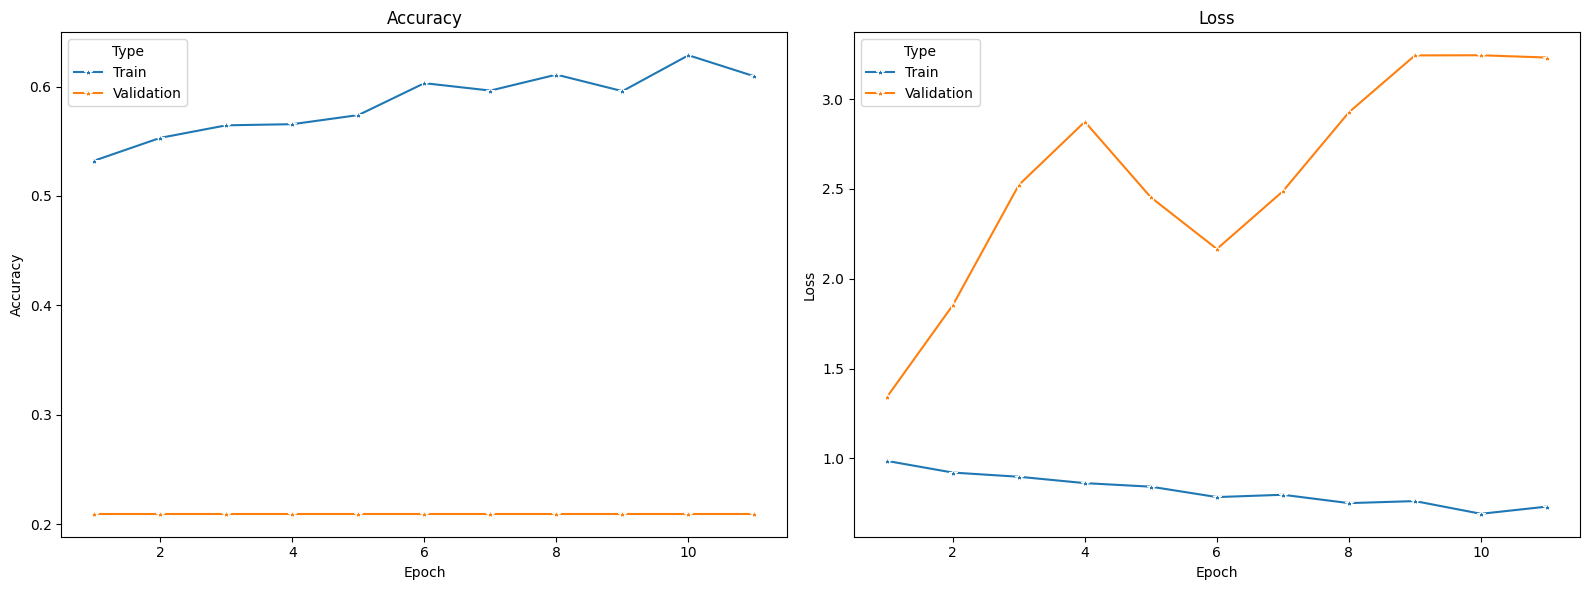

In [90]:
# Extract values
acc = cnn_history.history['accuracy']
val_acc = cnn_history.history['val_accuracy']
loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

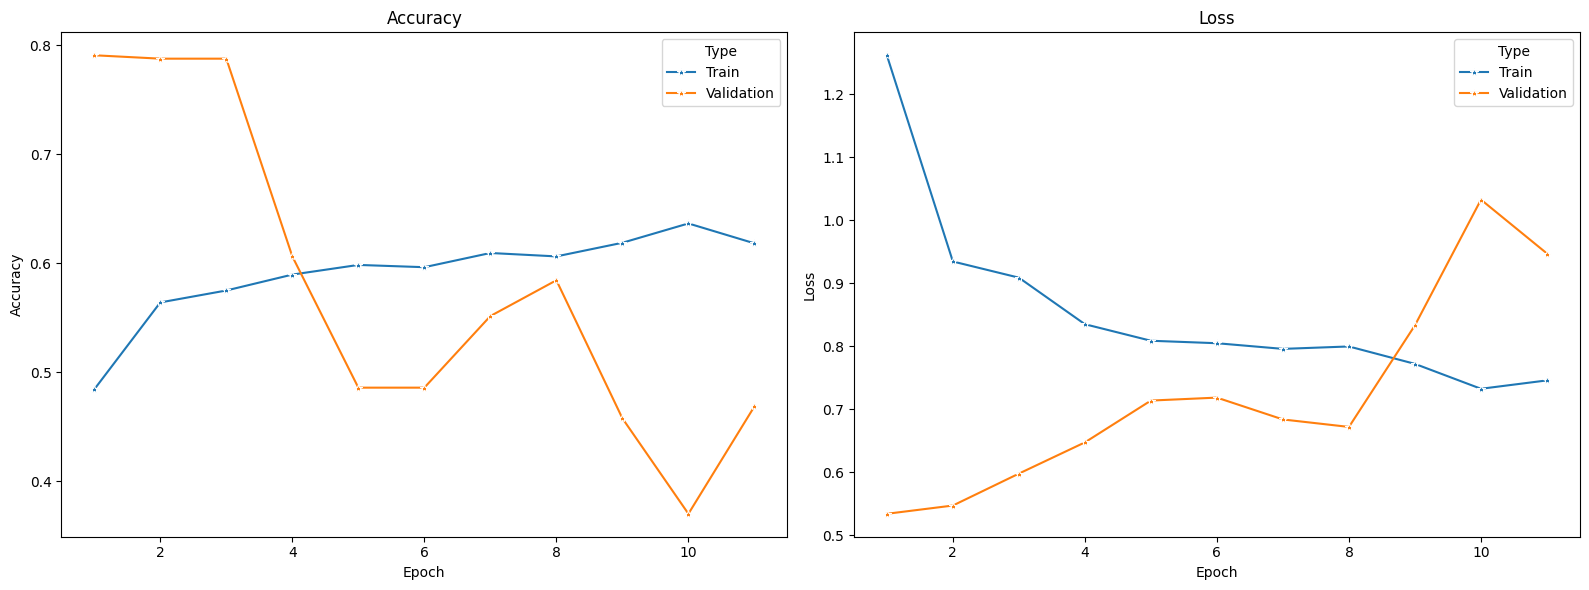

In [91]:
acc = vgg_history.history['accuracy']
val_acc = vgg_history.history['val_accuracy']
loss = vgg_history.history['loss']
val_loss = vgg_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

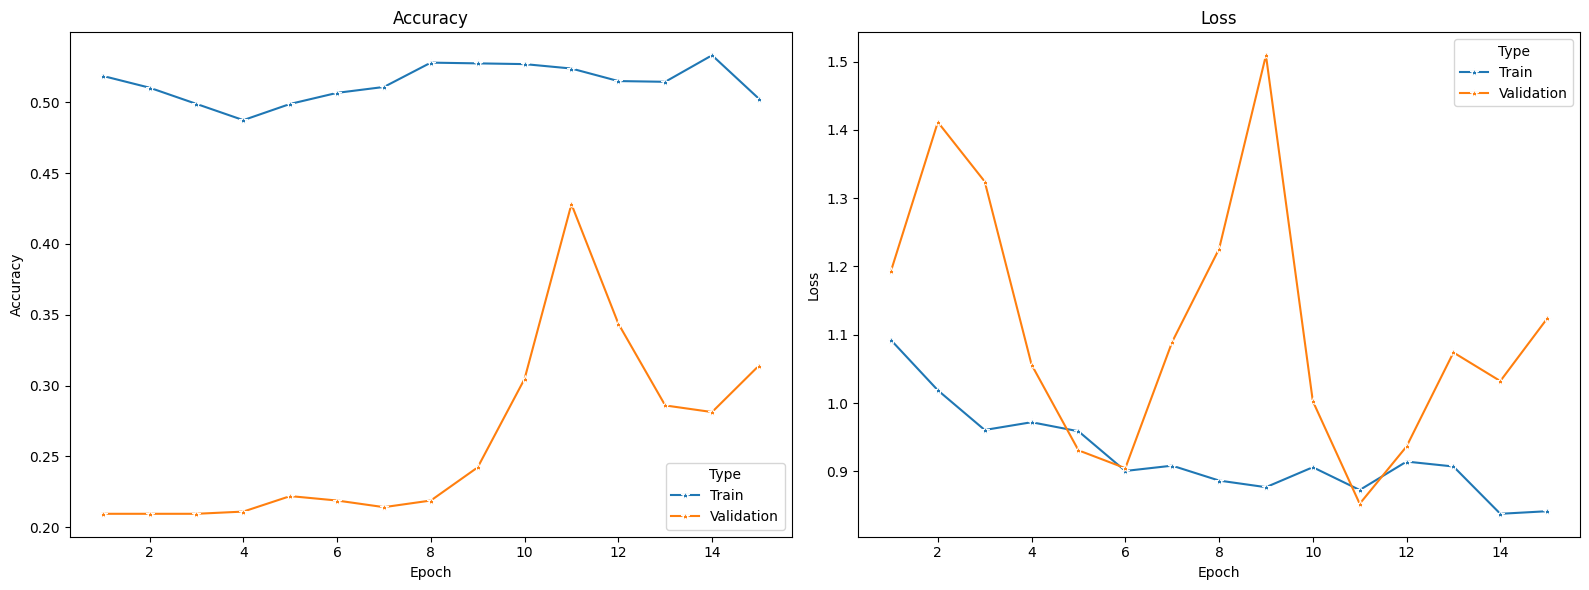

In [92]:
acc = resnet_history.history['accuracy']
val_acc = resnet_history.history['val_accuracy']
loss = resnet_history.history['loss']
val_loss = resnet_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

## **Confusion Matrix**

10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 8s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step


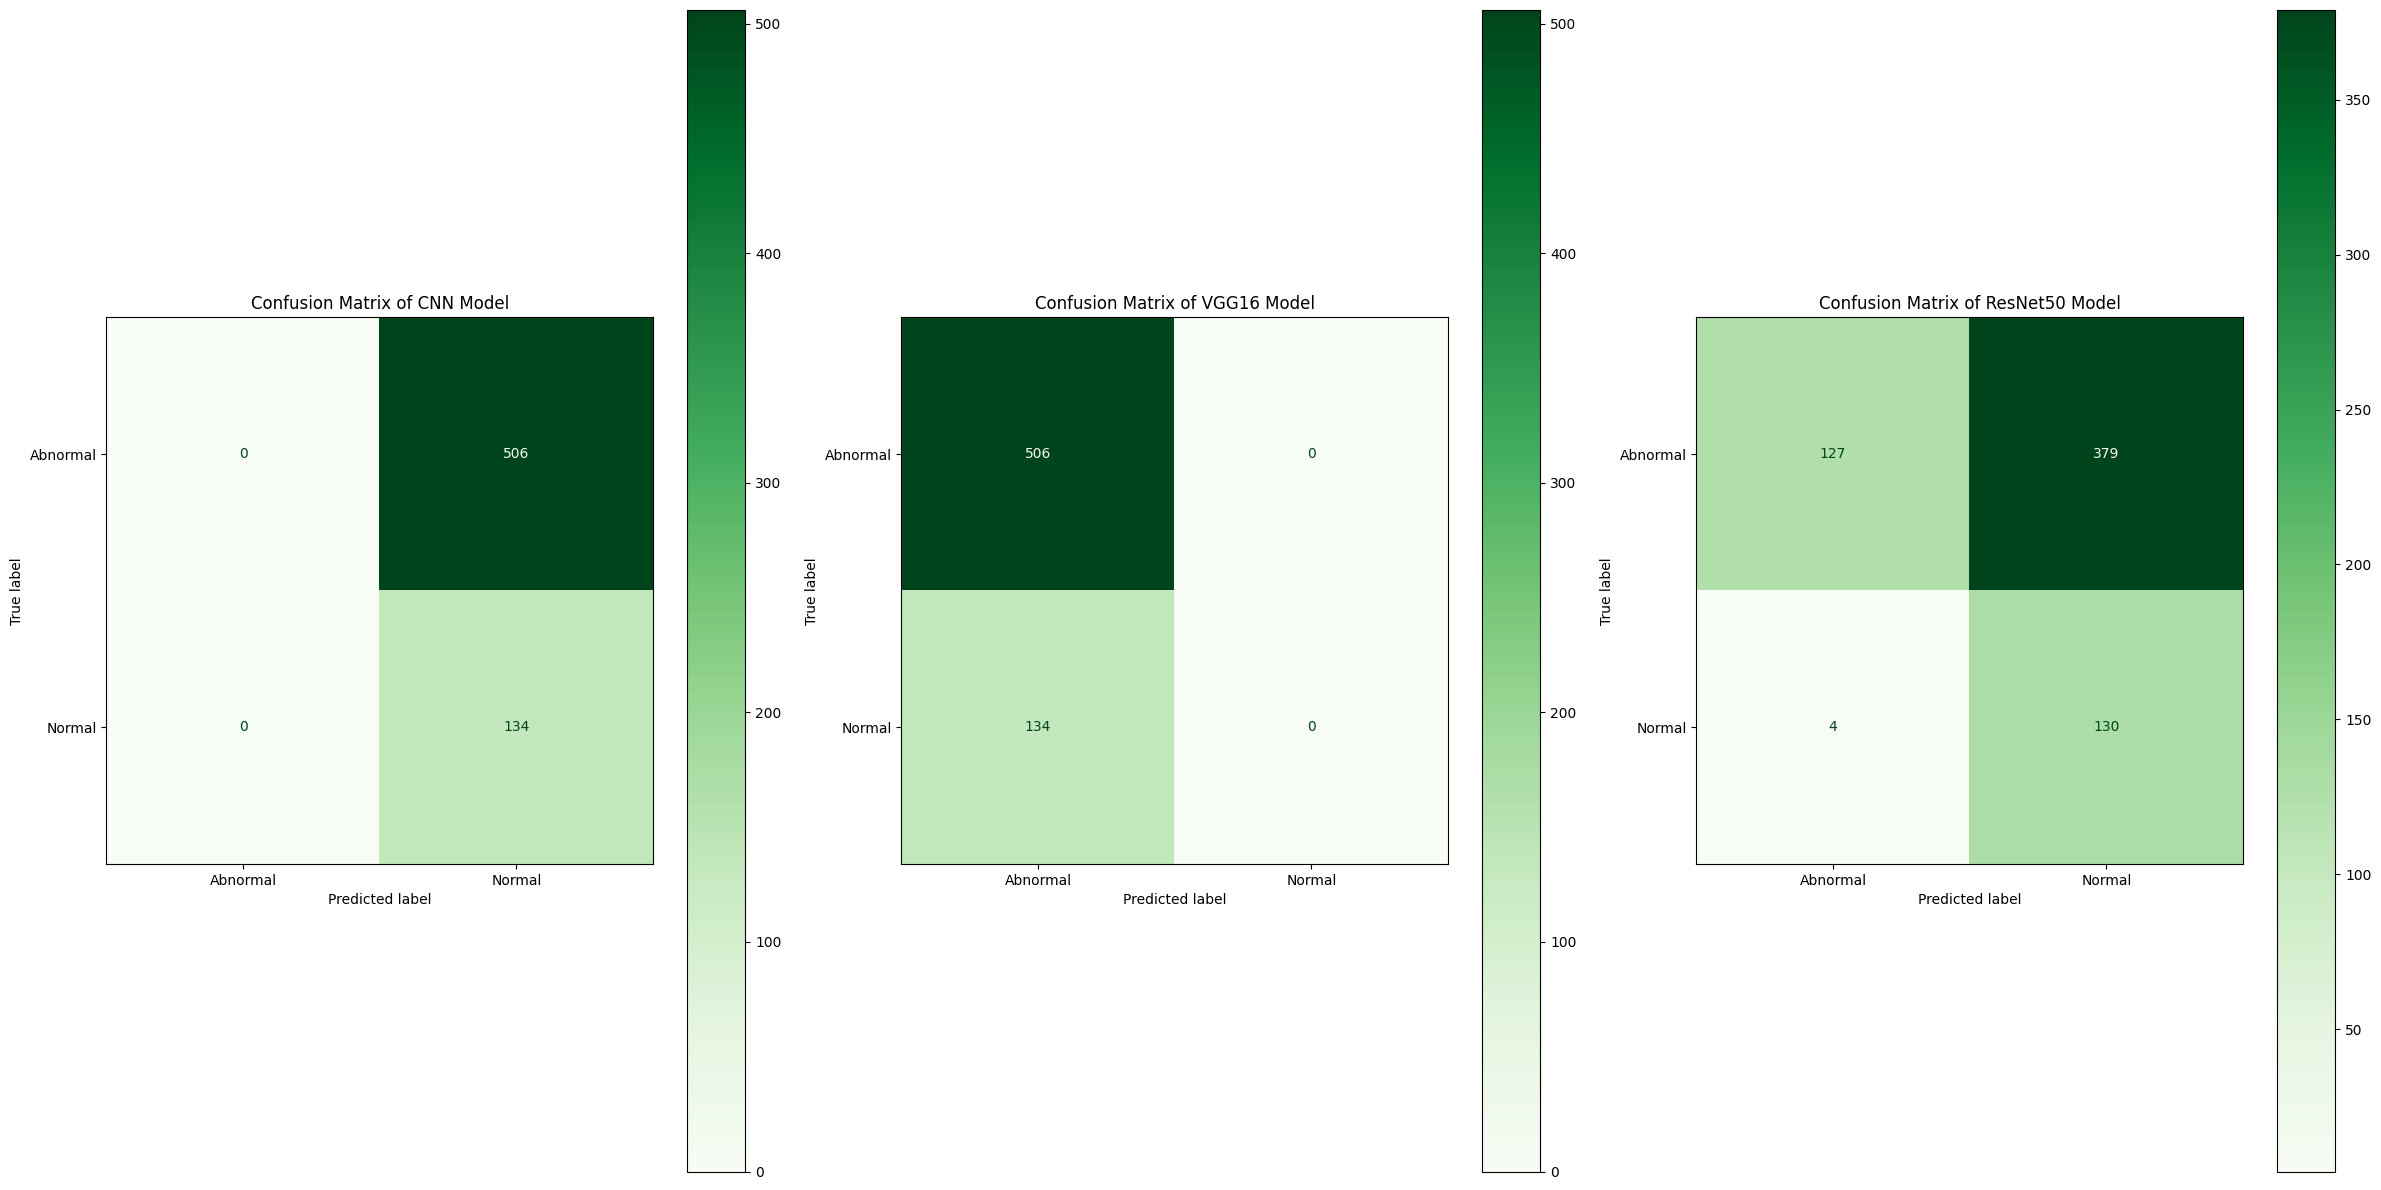

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_generator.reset()

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

fig, axes = plt.subplots(1, 3, figsize=(24, 12)) # 1 row, 3 columns

# --- CNN Model Confusion Matrix ---
y_pred_probs_cnn = cnn_model.predict(test_generator)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_labels)
disp_cnn.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[0])
axes[0].set_title('Confusion Matrix of CNN Model')

# --- VGG16 Model Confusion Matrix ---
test_generator.reset()
y_pred_probs_vgg = vgg_model.predict(test_generator)
y_pred_vgg = np.argmax(y_pred_probs_vgg, axis=1)
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_labels)
disp_vgg.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[1])
axes[1].set_title('Confusion Matrix of VGG16 Model')

# --- ResNet50 Model Confusion Matrix ---
test_generator.reset()
y_pred_probs_resnet = resnet_model.predict(test_generator)
y_pred_resnet = np.argmax(y_pred_probs_resnet, axis=1)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_labels)
disp_resnet.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[2])
axes[2].set_title('Confusion Matrix of ResNet50 Model')

plt.tight_layout()
plt.show()

## **Comparison Plots**

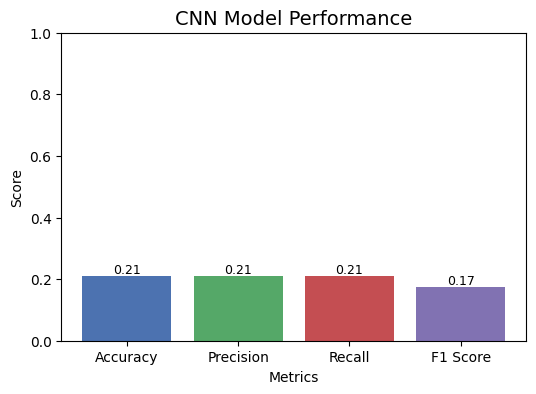

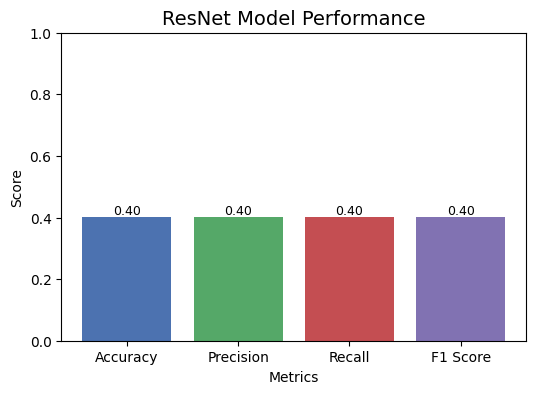

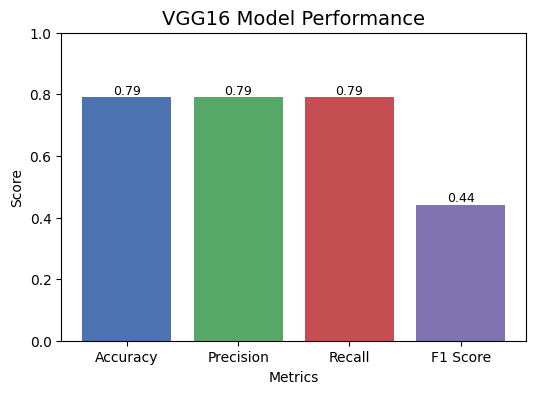

In [94]:
for idx, row in final_metrics.iterrows():
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    values = [row["Accuracy"], row["Precision"], row["Recall"], row["F1"]]

    plt.figure(figsize=(6,4))
    plt.bar(metrics, values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])

    # Add value labels on top
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

    plt.ylim(0, 1)  # since metrics are in range 0–1
    plt.title(f"{row['Model Name']} Performance", fontsize=14)
    plt.ylabel("Score")
    plt.xlabel("Metrics")
    plt.show()

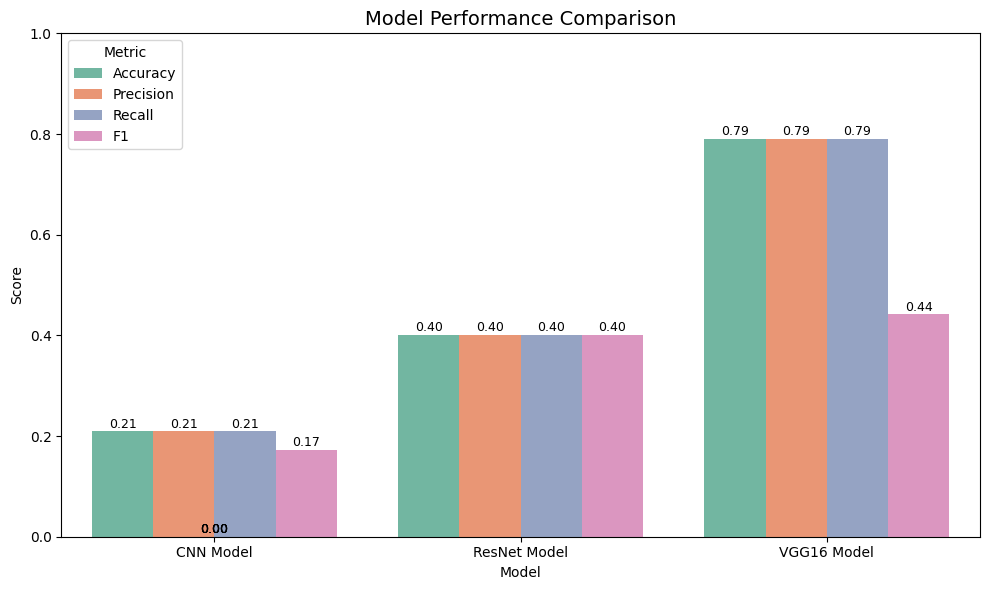

In [95]:
df_melted = final_metrics.melt(id_vars="Model Name", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Model Name", y="Score", hue="Metric", data=df_melted, palette="Set2")

# Add labels and title
plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.legend(title="Metric")

# Show values on bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

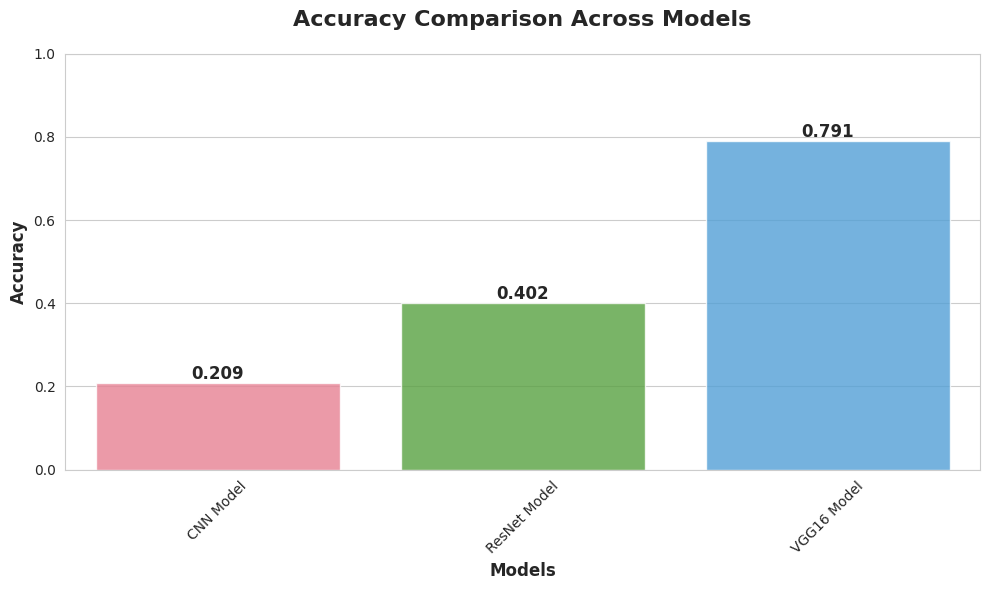

In [96]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
colors = sns.color_palette("husl", 3)  # Different colors for each model

# 1. Accuracy Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Accuracy', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Accuracy Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

# Add value annotations on bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

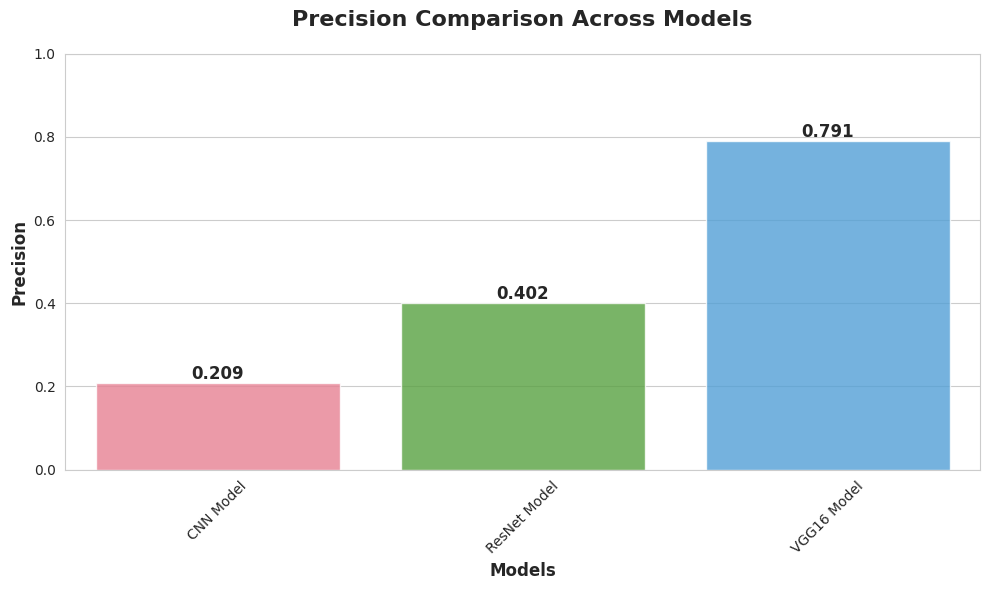

In [98]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Precision', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Precision Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

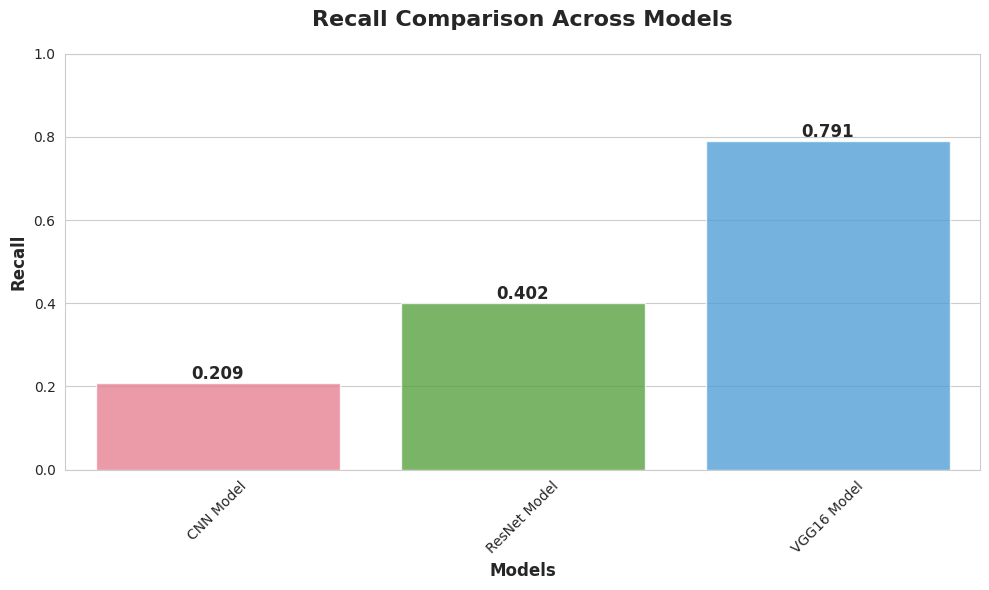

In [99]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Recall', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Recall Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Recall', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

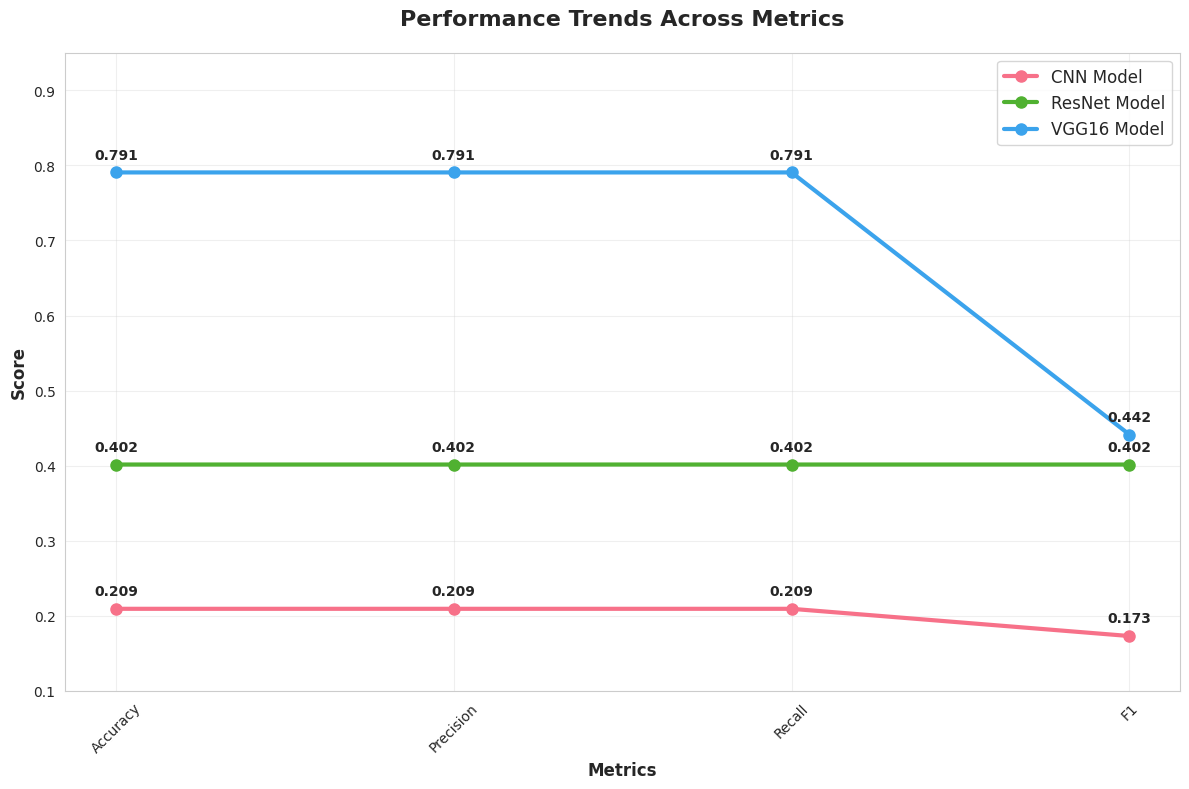

In [100]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
df_melted = final_metrics.melt(id_vars=['Model Name'], value_vars=metrics,
                   var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 8))
for i, model in enumerate(final_metrics['Model Name']):
    model_data = final_metrics[final_metrics['Model Name'] == model]
    plt.plot(metrics, model_data[metrics].values[0],
             marker='o', linewidth=3, markersize=8,
             label=model, color=colors[i])

plt.title('Performance Trends Across Metrics', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.ylim(0.1, 0.95)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add value annotations
for i, model in enumerate(final_metrics['Model Name']):
    model_data = final_metrics[final_metrics['Model Name'] == model]
    for j, metric in enumerate(metrics):
        plt.annotate(f'{model_data[metric].values[0]:.3f}',
                    (j, model_data[metric].values[0]),
                    textcoords="offset points",
                    xytext=(0,10),
                    ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **Test Predictions**

In [101]:
class_labels = list(test_generator.class_indices.keys())

def get_random_test_images(num_images=5):
    test_image_paths = []
    for class_folder in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_folder)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                test_image_paths.append(os.path.join(class_path, img_name))

    # Randomly select num_images image paths
    random.shuffle(test_image_paths)
    return test_image_paths[:num_images]

In [104]:
def preprocess_image(image_path, target_size=img_size):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

# Get 5 random test images
random_image_paths = get_random_test_images(num_images=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


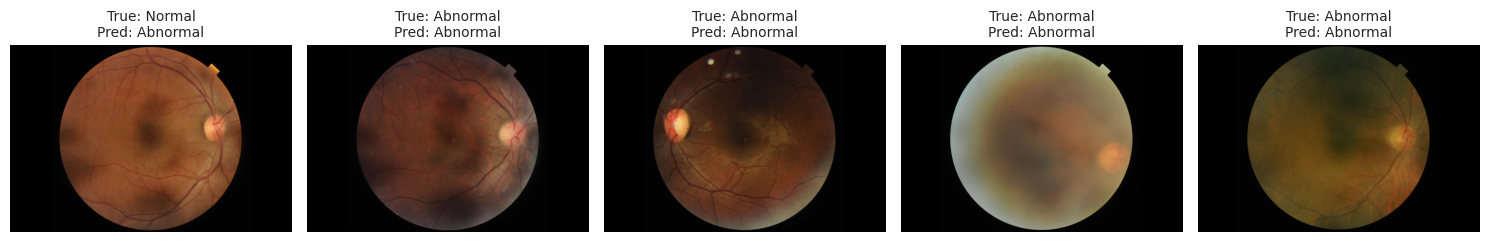

In [105]:
plt.figure(figsize=(15, 8))
for i, img_path in enumerate(random_image_paths):
    # Preprocess the image
    processed_img = preprocess_image(img_path)

    # Make prediction using VGG16 model
    predictions = vgg_model.predict(processed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_label = class_labels[predicted_class_index]

    # Get true label from the path
    true_label = os.path.basename(os.path.dirname(img_path))

    # Display the image and prediction
    plt.subplot(1, 5, i + 1)
    plt.imshow(Image.open(img_path))
    plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Grad-CAM**

In [106]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


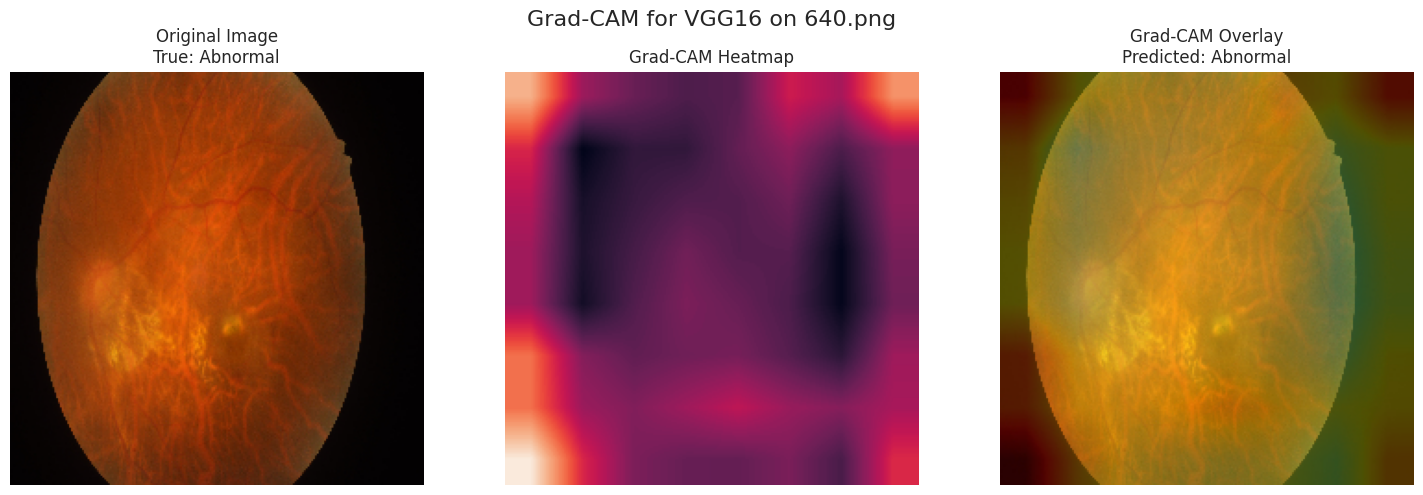

In [107]:
random_image_paths = get_random_test_images(num_images=1)
if not random_image_paths:
    print("No images found in the test directory.")
else:
    img_path = random_image_paths[0]
    preprocessed_image = preprocess_image(img_path)

    predictions = vgg_model.predict(preprocessed_image)
    predicted_class_index = np.argmax(predictions[0])
    predicted_label = class_labels[predicted_class_index]
    true_label = os.path.basename(os.path.dirname(img_path))

    last_conv_layer_name = 'block5_conv3'

    heatmap = make_gradcam_heatmap(preprocessed_image, vgg_model, last_conv_layer_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps['jet']
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = np.array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Original Image\nTrue: {true_label}")
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f"Grad-CAM Overlay\nPredicted: {predicted_label}")
    axes[2].axis('off')

    plt.suptitle(f"Grad-CAM for VGG16 on {os.path.basename(img_path)}", fontsize=16)
    plt.tight_layout()
    plt.show()